# Getting Started: explicit products & vintage-specific fleet modeling in `bw_timex`

This notebook walks new users through the **explicit product/process paradigm**
in Brightway and shows how `bw_timex` uses it to model a small fleet of heat
pumps. We do *not* use `flodym` here — all stock and lifetime numbers are
hand-typed so the moving parts stay visible.

## What you will learn

The notebook is split into two parts, each a complete worked example:

**Part 1 — Fleet/operation pattern.** The simplest possible time-explicit
fleet: one product (`heat`), one process (`heat_pump_operation`) representing
an HP running at one moment, and a `TemporalDistribution` *on the demand* to
say "deliver this much heat in these calendar years." Demonstrates the
newer `demand={product: TD}` feature of `bw_timex`.

**Part 2 — Lifecycle pattern with vintage lock-in.** A richer model with
two products (`heat_pump`, `heat_pump_unit`) and two processes
(`heat_pump_production`, `heat_pump_lifecycle`). One invocation of
`heat_pump_lifecycle` represents the whole life of one HP cohort:

- output-side **install RTD** on the production edge → spawns cohorts by
  install year,
- input-side **age survival RTD** on the electricity edge → spreads each
  cohort's electricity over the years it is actually running, with some
  HPs retiring early (Weibull-ish, hand-typed),
- `temporal_evolution_factors` + `temporal_evolution_reference="consumer"` →
  efficiency is **locked to the install year** for the whole life of each
  cohort,
- input-side **retirement PDF RTD** on the refrigerant-leak edge → end-of-
  life emissions happen on the right calendar years.

This is the same recipe used in the EV-fleet notebook
(`example_electric_vehicle_fleet_explicit_process_product.ipynb`), stripped
of the dMFA machinery and applied to heat pumps.

**Which pattern do I want?**

| Question                                                                       | Use         |
|--------------------------------------------------------------------------------|-------------|
| "How much CO₂ from delivering X kWh of heat over Y calendar years?"            | Part 1       |
| "What if some HPs are installed in 2025, others in 2035, and each keeps its install-year efficiency for its whole life — with some failing earlier than others?" | Part 2       |

Both patterns work in the same project; you can run them side by side.

## Project setup and background databases

Two electricity markets — one for 2025 (high CO₂ intensity) and one for 2035
(decarbonized). The biosphere has `CO2` and `refrigerant_leak`, and the
method characterizes both (CO₂ at 1 kg CO₂-eq/kg, refrigerant at ≈ 2 088 kg
CO₂-eq/kg, roughly R-410A's GWP100). Making refrigerant a real characterized
flow means EOL emissions actually show up in the score, which we will need
later.

In [1]:
from datetime import datetime

import bw2data as bd
import numpy as np
from bw_temporalis import TemporalDistribution

bd.projects.set_current("getting_started_explicit_process_product_heatpump")

for db in list(bd.databases):
    del bd.databases[db]
for method in list(bd.methods):
    del bd.methods[method]

bd.Database("biosphere").write(
    {
        ("biosphere", "CO2"): {
            "type": "emission",
            "name": "CO2",
            "unit": "kg",
        },
        ("biosphere", "refrigerant_leak"): {
            "type": "emission",
            "name": "refrigerant_leak",
            "unit": "kg",
        },
    }
)

for db_name, co2_per_kwh in [
    ("electricity_market_2025", 0.40),
    ("electricity_market_2035", 0.10),
]:
    bd.Database(db_name).write(
        {
            (db_name, "elec"): {
                "name": "electricity market",
                "reference product": "electricity",
                "location": "DE",
                "unit": "kWh",
                "exchanges": [
                    {"amount": 1, "type": "production", "input": (db_name, "elec")},
                    {"amount": co2_per_kwh, "type": "biosphere", "input": ("biosphere", "CO2")},
                ],
            }
        }
    )

bd.Method(("GWP", "100")).write(
    [
        (("biosphere", "CO2"), 1.0),
        (("biosphere", "refrigerant_leak"), 2088.0),  # R-410A GWP100
    ]
)

database_dates = {
    "electricity_market_2025": datetime(2025, 1, 1),
    "electricity_market_2035": datetime(2035, 1, 1),
    "foreground": "dynamic",
}

100%|██████████| 2/2 [00:00<00:00, 12501.65it/s]

15:07:46+0200 [info     ] Vacuuming database            



100%|██████████| 1/1 [00:00<00:00, 13662.23it/s]

15:07:46+0200 [info     ] Vacuuming database            



100%|██████████| 1/1 [00:00<00:00, 21620.12it/s]

15:07:46+0200 [info     ] Vacuuming database            


# Part 1 — Fleet/operation pattern with a demand `TemporalDistribution`

We start with the **simplest** thing that buys us time-explicit accounting:
one process representing the heat pump running at *one* moment in time, one
product representing the heat it delivers, and a TD *on the demand* to tell
`bw_timex` when the heat is needed.

```mermaid
flowchart LR
subgraph background[<i>background</i>]
    E25(["electricity_market_2025"]):::bg
    E35(["electricity_market_2035"]):::bg
end
subgraph foreground[<i>foreground</i>]
    HEAT([heat]):::product
    HPOP("heat_pump_operation"):::fg
end
subgraph biosphere[<i>biosphere</i>]
    R("refrigerant_leak"):::bio
    CO2("CO2"):::bio
end
HPOP-->|"1 kWh"|HEAT
E25-->|"0.33 kWh"|HPOP
E35-->|"0.33 kWh"|HPOP
HPOP-.->|"5e-5 kg"|R
classDef fg color:#222832, fill:#3fb1c5, stroke:none;
classDef product color:#222832, fill:#9c5ffd, stroke:none;
classDef bg color:#222832, fill:#3fb1c5, stroke:none;
classDef bio color:#222832, fill:#9c5ffd, stroke:none;
style background fill:none, stroke:none;
style foreground fill:none, stroke:none;
style biosphere fill:none, stroke:none;
```

**Explicit paradigm in three lines:**

- A **product node** (`type=bd.labels.product_node_default`) is a *thing* —
  a kWh of heat. Bare metadata, no exchanges.
- A **process node** (`type=bd.labels.process_node_default`) is an
  *operation*. Owns all the technosphere/biosphere/production edges.
- The process has one **production edge** pointing at the product. The
  product never has any exchanges of its own.

In this Part 1 the operation has no lifetime, no install vintage, no aging —
it is just "one HP, one moment." Where the temporal complexity lives is
*outside* the model, on the demand.

In [2]:
bd.Database("foreground").write(
    {
        ("foreground", "heat"): {
            "name": "heat",
            "type": bd.labels.product_node_default,
            "unit": "kWh",
            "location": "DE",
            "exchanges": [],
        },
        ("foreground", "heat_pump_operation"): {
            "name": "heat_pump_operation",
            "type": bd.labels.process_node_default,
            "unit": "kWh",
            "location": "DE",
            "exchanges": [
                {
                    "amount": 1,
                    "type": bd.labels.production_edge_default,
                    "input": ("foreground", "heat"),
                },
                {
                    "amount": 0.33,
                    "type": bd.labels.consumption_edge_default,
                    "input": ("electricity_market_2025", "elec"),
                },
                {
                    "amount": 5e-5,  # kg refrigerant leak per kWh heat
                    "type": "biosphere",
                    "input": ("biosphere", "refrigerant_leak"),
                },
            ],
        },
    }
)
for db in bd.databases:
    bd.Database(db).process()

100%|██████████| 2/2 [00:00<00:00, 52758.54it/s]

15:07:46+0200 [info     ] Vacuuming database            


## Demand as a `TemporalDistribution`

Normal Brightway demand looks like `{heat: 1000}` — 1000 kWh of heat with no
timing info. `bw_timex` then collapses everything to a single point in time
(`starting_datetime`) and the whole fleet would draw from one grid year.
Not what a real fleet does.

`bw_timex` now accepts a `TemporalDistribution` as a demand value:

```python
demand = {heat: TemporalDistribution(
    date=np.array([datetime(2025,1,1), ..., datetime(2044,1,1)], dtype='datetime64[s]'),
    amount=np.array([heat_in_2025, ..., heat_in_2044]),
)}
```

Read literally: *"deliver this many kWh of heat in 2025, this many in 2026,
…"*. Each row spawns its own cohort of the operation process at that year,
and its electricity input is linked to the matching background grid year.

**Rules for the demand TD:** dates must be **absolute** `datetime64`
(not relative timedeltas — demand sits at the top of the supply chain),
amounts are in the unit of the demanded product, and finer resolution
(monthly, hourly) is fine as long as `temporal_grouping` matches.

In [3]:
from bw_timex import TimexLCA

# Logistic ramp-up: a small district adopting HPs across 2025-2044.
years = np.arange(2025, 2045)
heat_per_year_kwh = 1_000_000 / (1 + np.exp(-0.6 * (years - 2030)))

heat_demand_td = TemporalDistribution(
    date=np.array([datetime(int(y), 1, 1) for y in years], dtype="datetime64[s]"),
    amount=heat_per_year_kwh,
)

heat = bd.get_node(database="foreground", code="heat")

tlca_part1 = TimexLCA(
    demand={heat: heat_demand_td},
    method=("GWP", "100"),
    database_dates=database_dates,
)
tlca_part1.build_timeline(
    starting_datetime=datetime(2025, 1, 1),
    temporal_grouping="year",
)
tlca_part1.lci()
tlca_part1.static_lcia()

print(f"Total heat demanded:      {heat_per_year_kwh.sum():>14,.0f} kWh")
print(f"Static base LCA score:    {tlca_part1.base_lca.score:>14,.0f} kg CO2-eq")
print(f"Time-explicit score:      {tlca_part1.static_score:>14,.0f} kg CO2-eq")

2026-05-27 15:07:46.946 | INFO     | bw_timex.timex_lca:__init__:137 - Initializing TimexLCA object...
2026-05-27 15:07:46.946 | INFO     | bw_timex.timex_lca:__init__:170 - Calculating base LCA...
2026-05-27 15:07:46.958 | INFO     | bw_timex.timex_lca:__init__:187 - Collecting node infos...
2026-05-27 15:07:46.959 | INFO     | bw_timex.timex_lca:build_timeline:318 - No edge filter function provided. Skipping all edges in background databases.
2026-05-27 15:07:46.960 | INFO     | bw_timex.timex_lca:build_timeline:336 - Creating activity time mapping...
2026-05-27 15:07:46.961 | INFO     | bw_timex.timeline_builder:__init__:104 - Traversing supply chain graph...
2026-05-27 15:07:46.965 | INFO     | bw_timex.timeline_builder:build_timeline:163 - Building timeline...
2026-05-27 15:07:46.981 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:590 - Reference date 2036-01-01 00:00:00 is higher than all provided dates. Data will be taken from the close

Starting graph traversal
Calculation count: 1
Total heat demanded:          14,440,759 kWh
Static base LCA score:         3,413,795 kg CO2-eq
Time-explicit score:           2,143,801 kg CO2-eq


The time-explicit score is far below the static base score: most heat is
delivered in the late 2030s, when the grid is much cleaner, and the demand
TD correctly routes those cohorts to the 2035 grid.

**What this pattern cannot do:**

- *Vintage lock-in.* There is no concept of "install year" — each operation
  moment is its own moment. If you want "an HP installed in 2025 keeps its
  2025-tech efficiency for the next ten years even when it operates in
  2030," Part 1 can't express that.
- *Lifetime-distributed retirements.* No notion of HPs aging out across the
  years. Each cohort runs and dies at the same instant.
- *Embodied/manufacturing impacts split off cleanly.* The refrigerant
  leak is a per-kWh approximation, not an EOL event.

Part 2 fixes all three.

# Part 2 — Lifecycle pattern with vintage-locked efficiency

We now build a richer model where **one invocation of one process
represents the entire life of one HP cohort** — install, operate for many
years, retire. This is the lifecycle pattern, and it is the natural place
to express *vintage lock-in*: a 2025-vintage HP keeps its 2025 efficiency
for its whole life, regardless of what better tech exists by 2032.

## A tiny hand-typed "stock model"

We use only made-up numbers — no `flodym`, no `scipy`. The point is to see
how the three distributions fit together. They live on three different
edges of the lifecycle process and `bw_timex` convolves them for us.

**1. Install RTD** (calendar-year offsets, on the production edge). Says
*when in calendar time HPs are installed*. Three cohorts in 2025, 2030,
2035 with shares 0.30 / 0.40 / 0.30.

**2. Use age TD** (age-relative, on the electricity edge). A survival-like
profile: weight at age `a` = `SF(a)/mean_lifetime`, where `SF` is the
fraction of the cohort still operating at age `a`. Most HPs are alive for
10 years, then a tail of retirements over the next 7 — exactly the
"some HPs go out of service earlier" behavior, captured at the cohort
level. (Same idea as the Weibull survival function in the EV-fleet
notebook, but hand-typed.)

**3. EOL retirement PDF** (age-relative, on the refrigerant-leak edge).
The retirement event happens once per HP, distributed over age according
to a hand-typed PDF (the per-age decrements of the survival function).

**4. Vintage COP factors.** Newer HPs use less electricity per kWh of
heat. Keyed by install year. Locked to the cohort via
`temporal_evolution_reference="consumer"`.

In [4]:
# --- Install cohorts: three install years (relative to starting_datetime=2025) ---
td_install = TemporalDistribution(
    date=np.array([0, 5, 10], dtype="timedelta64[Y]"),
    amount=np.array([0.30, 0.40, 0.30]),  # cohort weights — sum to 1
)

# --- Age survival profile (hand-typed Weibull-ish, 18 age bins) ---
# SF[a] = fraction of a cohort still operating at age a.
ages = np.arange(0, 18)
survival = np.array(
    [
        1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00,
        0.95, 0.90, 0.80, 0.65, 0.50, 0.30, 0.15, 0.05,
    ]
)
mean_lifetime = float(survival.sum())  # ≈ 14.3 years

td_use_age = TemporalDistribution(
    date=ages.astype("timedelta64[Y]"),
    amount=survival / mean_lifetime,  # normalized to sum to 1
)

# --- EOL retirement PDF: how many HPs retire at each age. ---
# Derived from the survival function: PDF[a] ≈ SF[a-1] - SF[a].
retirement_pdf = np.zeros_like(survival)
retirement_pdf[1:] = survival[:-1] - survival[1:]
retirement_pdf[-1] += survival[-1]  # everyone left retires at the last age
# Should sum to 1 — every HP retires exactly once.
td_eol_age = TemporalDistribution(
    date=ages.astype("timedelta64[Y]"),
    amount=retirement_pdf,
)

# --- Vintage-locked COP factors: newer HPs use less electricity. ---
vintage_cop_factors = {
    datetime(2025, 1, 1): 1.00,   # baseline 0.33 kWh elec per kWh heat
    datetime(2030, 1, 1): 0.85,
    datetime(2035, 1, 1): 0.70,   # 30 % less per kWh heat
}

print(f"Mean lifetime (Σ SF):     {mean_lifetime:>6.2f} years")
print(f"Σ install shares:         {td_install.amount.sum():>6.2f}")
print(f"Σ use-age weights:        {td_use_age.amount.sum():>6.2f}")
print(f"Σ EOL PDF weights:        {td_eol_age.amount.sum():>6.2f}")

Mean lifetime (Σ SF):      14.30 years
Σ install shares:           1.00
Σ use-age weights:          1.00
Σ EOL PDF weights:          1.00


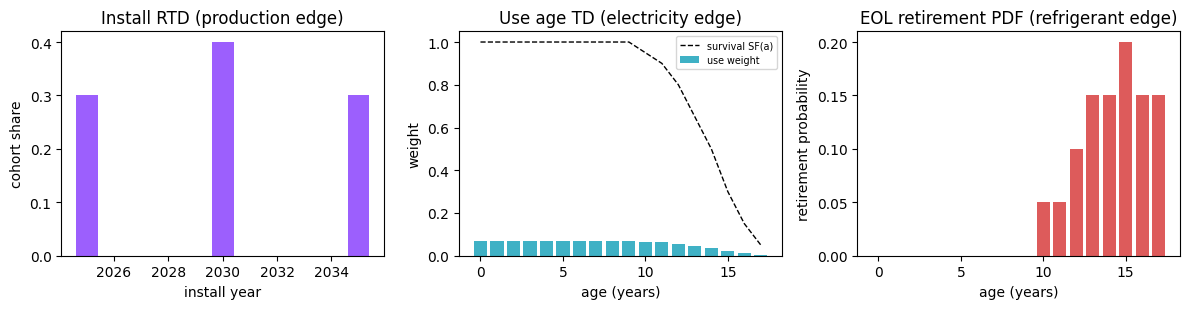

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))

install_years = 2025 + td_install.date.astype("timedelta64[Y]").astype(int)
axes[0].bar(install_years, td_install.amount, color="#9c5ffd")
axes[0].set(xlabel="install year", ylabel="cohort share",
            title="Install RTD (production edge)")

axes[1].bar(ages, td_use_age.amount, color="#3fb1c5", label="use weight")
axes[1].plot(ages, survival, "k--", lw=1, label="survival SF(a)")
axes[1].set(xlabel="age (years)", ylabel="weight",
            title="Use age TD (electricity edge)")
axes[1].legend(fontsize="x-small")

axes[2].bar(ages, td_eol_age.amount, color="#dd5b5b")
axes[2].set(xlabel="age (years)", ylabel="retirement probability",
            title="EOL retirement PDF (refrigerant edge)")

fig.tight_layout()

## Foreground for Part 2: two products, two processes

```mermaid
flowchart LR
subgraph background[<i>background</i>]
    E25(["electricity_market_2025"]):::bg
    E35(["electricity_market_2035"]):::bg
end
subgraph foreground[<i>foreground</i>]
    HP([heat_pump]):::product
    HPPROD("heat_pump_production"):::fg
    HPU([heat_pump_unit]):::product
    HPLC("heat_pump_lifecycle"):::fg
end
subgraph biosphere[<i>biosphere</i>]
    R("refrigerant_leak"):::bio
end
HPPROD-->|"1 unit"|HP
HPLC-->|"1 unit · install RTD"|HPU
HP-->|"1 unit"|HPLC
E25-->|"500 kWh"|HPPROD
E25-->|"use age TD · vintage COP factors"|HPLC
E35-->|"use age TD · vintage COP factors"|HPLC
HPLC-.->|"1 kg · EOL retirement TD"|R
classDef fg color:#222832, fill:#3fb1c5, stroke:none;
classDef product color:#222832, fill:#9c5ffd, stroke:none;
classDef bg color:#222832, fill:#3fb1c5, stroke:none;
classDef bio color:#222832, fill:#9c5ffd, stroke:none;
style background fill:none, stroke:none;
style foreground fill:none, stroke:none;
style biosphere fill:none, stroke:none;
```

Roles:

- **`heat_pump` (product)** — the physical device, bare metadata.
- **`heat_pump_production` (process)** — manufactures one HP. Modeled
  simply as 500 kWh of electricity per unit (stand-in for materials and
  factory energy).
- **`heat_pump_unit` (product)** — the abstract *HP-lifetime* unit, bare.
  This is what we will **demand**: "give me 1 000 HPs, full lives."
- **`heat_pump_lifecycle` (process)** — one invocation = one HP cohort
  through its entire life. Its edges carry all three RTDs:
  - production edge → `heat_pump_unit`, with `td_install` (when this
    cohort comes online);
  - capital edge ← `heat_pump`, no TD (built at the install year);
  - use edge ← electricity, with `td_use_age` and vintage-locked COP
    factors (`reference="consumer"` → factor follows the install year);
  - biosphere edge → `refrigerant_leak`, with `td_eol_age` (the disposal
    leak happens at the retirement age of each cohort, not at install).

Per-HP amounts: lifetime electricity = `annual_heat × elec_per_heat ×
mean_lifetime`. `bw_timex` then multiplies that scalar by the use age TD
(sum=1) to get the per-age electricity, and by the vintage factor at
`date_consumer` (= install year) to lock efficiency.

In [6]:
ANNUAL_HEAT = 5_000             # kWh of heat per HP per year
BASELINE_ELEC_PER_HEAT = 0.33   # kWh elec per kWh heat (COP ~ 3)
MANUFACTURING_ELEC = 500        # kWh per HP
REFRIGERANT_PER_HP = 1.0        # kg refrigerant released at EOL

LIFETIME_KWH_PER_HP = ANNUAL_HEAT * BASELINE_ELEC_PER_HEAT * mean_lifetime

# Add the Part-2 nodes to the same foreground database.
fg = bd.Database("foreground")

heat_pump = fg.new_node(
    code="heat_pump",
    name="heat_pump",
    type=bd.labels.product_node_default,
    unit="unit",
    location="DE",
)
heat_pump.save()

hp_production = fg.new_node(
    code="heat_pump_production",
    name="heat_pump_production",
    type=bd.labels.process_node_default,
    unit="unit",
    location="DE",
)
hp_production.save()
hp_production.new_edge(input=heat_pump, amount=1, type=bd.labels.production_edge_default).save()
hp_production.new_edge(
    input=bd.get_node(database="electricity_market_2025", code="elec"),
    amount=MANUFACTURING_ELEC,
    type=bd.labels.consumption_edge_default,
).save()

heat_pump_unit = fg.new_node(
    code="heat_pump_unit",
    name="heat_pump_unit (HP-lifetime)",
    type=bd.labels.product_node_default,
    unit="HP-lifetime",
    location="DE",
)
heat_pump_unit.save()

hp_lifecycle = fg.new_node(
    code="heat_pump_lifecycle",
    name="heat_pump_lifecycle",
    type=bd.labels.process_node_default,
    unit="HP-lifetime",
    location="DE",
)
hp_lifecycle.save()

# (1) Output side: production edge with install RTD.
hp_lifecycle.new_edge(
    input=heat_pump_unit,
    amount=1,
    type=bd.labels.production_edge_default,
    temporal_distribution=td_install,
).save()

# Capital: one HP per HP-lifetime, no TD (built at the install year).
hp_lifecycle.new_edge(
    input=heat_pump,
    amount=1,
    type=bd.labels.consumption_edge_default,
).save()

# (2,4) Use phase: lifetime kWh spread across ages by td_use_age, with
# vintage-locked COP factors (reference="consumer" → install year).
elec_edge = hp_lifecycle.new_edge(
    input=bd.get_node(database="electricity_market_2025", code="elec"),
    amount=LIFETIME_KWH_PER_HP,
    type=bd.labels.consumption_edge_default,
    temporal_distribution=td_use_age,
)
elec_edge["temporal_evolution_factors"] = vintage_cop_factors
elec_edge["temporal_evolution_reference"] = "consumer"
elec_edge.save()

# (3) End-of-life: refrigerant leak distributed across retirement ages.
hp_lifecycle.new_edge(
    input=bd.get_node(database="biosphere", code="refrigerant_leak"),
    amount=REFRIGERANT_PER_HP,
    type="biosphere",
    temporal_distribution=td_eol_age,
).save()

for db in bd.databases:
    bd.Database(db).process()

## Run the lifecycle TimexLCA

Functional unit: `1 000 heat_pump_unit` — *one thousand heat pumps over
their full lives*. The install RTD splits those 1 000 into three cohorts
of 300/400/300 HPs installed in 2025/2030/2035. Each cohort then lives
out its hand-typed survival profile.

In [7]:
FLEET_SIZE = 1_000

tlca_part2 = TimexLCA(
    demand={heat_pump_unit: FLEET_SIZE},
    method=("GWP", "100"),
    database_dates=database_dates,
)
tlca_part2.build_timeline(
    starting_datetime=datetime(2025, 1, 1),
    temporal_grouping="year",
)
tlca_part2.lci()
tlca_part2.static_lcia()

print(f"Lifecycle fleet ({FLEET_SIZE} HPs, vintage-locked) GWP100:")
print(f"  Static base LCA score: {tlca_part2.base_lca.score:>14,.0f} kg CO2-eq")
print(f"  Time-explicit score:   {tlca_part2.static_score:>14,.0f} kg CO2-eq")
print(f"  Per HP-lifetime:       {tlca_part2.static_score/FLEET_SIZE:>14,.0f} kg CO2-eq / HP")

2026-05-27 15:07:47.260 | INFO     | bw_timex.timex_lca:__init__:137 - Initializing TimexLCA object...
2026-05-27 15:07:47.261 | INFO     | bw_timex.timex_lca:__init__:170 - Calculating base LCA...
2026-05-27 15:07:47.269 | INFO     | bw_timex.timex_lca:__init__:187 - Collecting node infos...
2026-05-27 15:07:47.273 | INFO     | bw_timex.timex_lca:build_timeline:318 - No edge filter function provided. Skipping all edges in background databases.
2026-05-27 15:07:47.274 | INFO     | bw_timex.timex_lca:build_timeline:336 - Creating activity time mapping...
2026-05-27 15:07:47.274 | INFO     | bw_timex.timeline_builder:__init__:104 - Traversing supply chain graph...
2026-05-27 15:07:47.284 | INFO     | bw_timex.timeline_builder:build_timeline:163 - Building timeline...
2026-05-27 15:07:47.294 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:590 - Reference date 2036-01-01 00:00:00 is higher than all provided dates. Data will be taken from the close

Starting graph traversal
Calculation count: 3
Lifecycle fleet (1000 HPs, vintage-locked) GWP100:
  Static base LCA score:     11,726,000 kg CO2-eq
  Time-explicit score:        5,287,775 kg CO2-eq
  Per HP-lifetime:                5,288 kg CO2-eq / HP


## Validating that vintage lock-in actually holds

The clearest evidence sits in the electricity rows of the timeline. Each
row has two dates:

- `date_consumer` — the **install vintage** (cohort year), set by
  `td_install` on the production edge;
- `date_producer` — the **calendar year the electricity is actually
  drawn**, set by `td_use_age` (= install year + age).

Because of `temporal_evolution_reference="consumer"`, the COP factor is
looked up at `date_consumer`. So a 2025-vintage row should carry the
2025 factor (1.0 → 1 650 kWh per HP per age slice) *for every draw year
in its life*, while a 2035-vintage row should carry the 2035 factor
(0.7 → 1 155 kWh per HP per age slice) for every draw year in its life.

The grid mix that supplies each row still follows the *draw year*
(`date_producer`) — only efficiency is locked, not background sourcing.

In [8]:
elec_rows = tlca_part2.timeline[
    tlca_part2.timeline["producer_name"] == "electricity market"
].copy()
elec_rows["install_year"] = elec_rows["date_consumer"].dt.year
elec_rows["draw_year"] = elec_rows["date_producer"].dt.year

# Filter out the manufacturing electricity (heat_pump_production rows) for
# clarity — those are the small constant 500 kWh hits per HP, only at install.
use_rows = elec_rows[elec_rows["consumer_name"] == "heat_pump_lifecycle"]

use_rows[
    ["install_year", "draw_year", "amount", "temporal_market_shares"]
].sort_values(["install_year", "draw_year"]).head(20)

,install_year,draw_year,amount,temporal_market_shares
1,2025,2025,1650.0,{'electricity_market_2025': 1}
4,2025,2026,1650.0,"{'electricity_market_2025': 0.9, 'electricity_..."
5,2025,2027,1650.0,"{'electricity_market_2025': 0.8, 'electricity_..."
6,2025,2028,1650.0,"{'electricity_market_2025': 0.7, 'electricity_..."
7,2025,2029,1650.0,"{'electricity_market_2025': 0.6, 'electricity_..."
8,2025,2030,1650.0,"{'electricity_market_2025': 0.5, 'electricity_..."
13,2025,2031,1650.0,"{'electricity_market_2025': 0.4, 'electricity_..."
15,2025,2032,1650.0,"{'electricity_market_2025': 0.3, 'electricity_..."
17,2025,2033,1650.0,"{'electricity_market_2025': 0.2, 'electricity_..."
19,2025,2034,1650.0,"{'electricity_market_2025': 0.1, 'electricity_..."


Look at the `amount` column above. Within a given `install_year` block it
stays constant (modulo the survival weight at each age), regardless of how
the `draw_year` advances — that is vintage lock-in. Look at
`temporal_market_shares` for the same rows: the share of the 2035 grid
rises as `draw_year` advances, even though the vintage factor stays
fixed. Both halves of the picture are doing the right thing at the same
time.

## Vintage-locked vs. operation-year-referenced

To make the lock-in concrete: rerun with the same factor dict but
`reference="producer"`. Now the factor is looked up at the *operation*
year, not the install year — meaning a 2025-installed HP would magically
get 2035 efficiency once 2035 comes around.

| Setup                                | Factor looked up at | What it represents                             |
|--------------------------------------|---------------------|------------------------------------------------|
| `reference="consumer"` (our default)  | install year         | 2025 HP keeps 2025 efficiency for its whole life |
| `reference="producer"`                | draw year            | every HP operating in 2035 uses 2035 efficiency |

In [9]:
elec_edge["temporal_evolution_reference"] = "producer"
elec_edge.save()
bd.Database("foreground").process()

tlca_producer_ref = TimexLCA(
    demand={heat_pump_unit: FLEET_SIZE},
    method=("GWP", "100"),
    database_dates=database_dates,
)
tlca_producer_ref.build_timeline(
    starting_datetime=datetime(2025, 1, 1),
    temporal_grouping="year",
)
tlca_producer_ref.lci()
tlca_producer_ref.static_lcia()

# Restore so downstream cells stay consistent with vintage lock-in.
elec_edge["temporal_evolution_reference"] = "consumer"
elec_edge.save()
bd.Database("foreground").process()

diff = tlca_producer_ref.static_score - tlca_part2.static_score
print(f"Vintage-locked  (reference=consumer): {tlca_part2.static_score:>14,.0f} kg CO2-eq")
print(f"Operation-year  (reference=producer): {tlca_producer_ref.static_score:>14,.0f} kg CO2-eq")
print(
    f"Difference                            : {diff:>+14,.0f} kg CO2-eq "
    f"({100 * diff / tlca_part2.static_score:+.1f} %)"
)

2026-05-27 15:07:47.402 | INFO     | bw_timex.timex_lca:__init__:137 - Initializing TimexLCA object...
2026-05-27 15:07:47.402 | INFO     | bw_timex.timex_lca:__init__:170 - Calculating base LCA...
2026-05-27 15:07:47.408 | INFO     | bw_timex.timex_lca:__init__:187 - Collecting node infos...
2026-05-27 15:07:47.411 | INFO     | bw_timex.timex_lca:build_timeline:318 - No edge filter function provided. Skipping all edges in background databases.
2026-05-27 15:07:47.411 | INFO     | bw_timex.timex_lca:build_timeline:336 - Creating activity time mapping...
2026-05-27 15:07:47.412 | INFO     | bw_timex.timeline_builder:__init__:104 - Traversing supply chain graph...
2026-05-27 15:07:47.418 | INFO     | bw_timex.timeline_builder:build_timeline:163 - Building timeline...
2026-05-27 15:07:47.425 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:590 - Reference date 2036-01-01 00:00:00 is higher than all provided dates. Data will be taken from the close

Starting graph traversal
Calculation count: 3
Vintage-locked  (reference=consumer):      5,287,775 kg CO2-eq
Operation-year  (reference=producer):      4,959,854 kg CO2-eq
Difference                            :       -327,921 kg CO2-eq (-6.2 %)


`reference="producer"` is lower here because the 2025 cohort — which is
the largest in the early years — *also* gets to benefit from 2030 and
2035 efficiency once it operates in those years. That is what "the whole
fleet uses today's tech" means, and it is generally not what an LCA of
vintage-specific equipment wants. Use `"consumer"` for vintage lock-in;
use `"producer"` for system-wide upgrades that apply to all active
cohorts simultaneously (operational learning, retrofits, behavioural
changes).

## End-of-life: when do the refrigerant emissions actually land?

Biosphere flows do not show up in `tlca.timeline` — that view is for
technosphere edges. They live in `tlca.dynamic_inventory_df` instead, with
the right calendar-year stamp produced by the convolution of the install
RTD and the EOL retirement PDF. The plot below sums refrigerant-leak rows
across cohorts and shows them by year of disposal.

The 2025 cohort retires roughly 2035–2042, the 2030 cohort roughly
2040–2047, and the 2035 cohort roughly 2045–2052 — install year plus the
retirement-age PDF mass.

Total refrigerant released across the fleet: 1,000.0 kg (expected ≈ 1,000 kg)


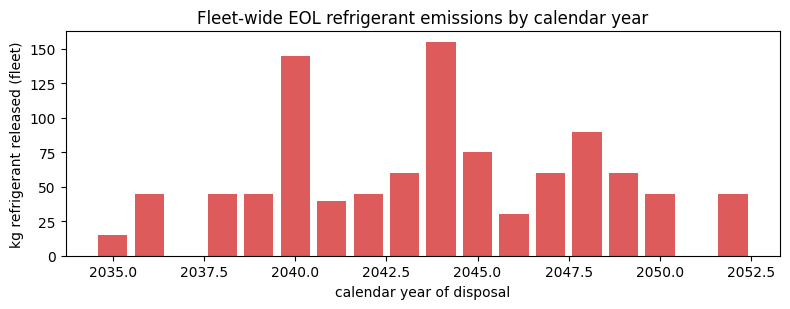

In [10]:
refrigerant_flow_id = bd.get_node(database="biosphere", code="refrigerant_leak").id

inv = tlca_part2.create_dynamic_inventory_dataframe()
ref_inv = inv[inv["flow"] == refrigerant_flow_id].copy()
ref_inv["year"] = ref_inv["date"].dt.year
by_disposal_year = ref_inv.groupby("year")["amount"].sum().sort_index()

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(by_disposal_year.index, by_disposal_year.values, color="#dd5b5b")
ax.set(
    xlabel="calendar year of disposal",
    ylabel="kg refrigerant released (fleet)",
    title="Fleet-wide EOL refrigerant emissions by calendar year",
)
fig.tight_layout()

print(
    f"Total refrigerant released across the fleet: "
    f"{by_disposal_year.sum():,.1f} kg "
    f"(expected ≈ {FLEET_SIZE * REFRIGERANT_PER_HP:,.0f} kg)"
)

## Recap and decision guide

### What the pieces do

| Piece                                                  | Job in the model                                         |
|--------------------------------------------------------|----------------------------------------------------------|
| Product node (`bd.labels.product_node_default`)        | Bare metadata: a *thing* that can be demanded            |
| Process node (`bd.labels.process_node_default`)        | Owns all exchanges; one production edge per product      |
| `{product: float}` demand                              | Single point in time at `starting_datetime`              |
| `{product: TemporalDistribution}` demand               | Spawn one cohort per absolute-date entry in the TD       |
| Output-side RTD on production edge (timedelta dates)   | Cohorts relative to the consumer/FU                      |
| Input-side RTD on consumption/biosphere edges           | Per-unit lifetime profile relative to the consumer       |
| `temporal_evolution_factors` + `reference="consumer"`   | Vintage lock-in (factor follows install year)            |
| `temporal_evolution_factors` + `reference="producer"`   | Operation-year change (factor follows actual draw year)  |

### Pattern picker

| Modeling question                                                            | Pattern                                            |
|------------------------------------------------------------------------------|----------------------------------------------------|
| "X kWh of heat across 20 years, simple grid evolution"                       | Part 1 — fleet/operation with demand TD             |
| "100 HPs installed in different years, each keeping its install efficiency"  | Part 2 — lifecycle with install RTD + vintage lock  |
| "Embodied/manufacturing impacts amortized cleanly across HP life"            | Part 2 (capital edge `heat_pump → lifecycle`)       |
| "Some HPs fail earlier; EOL emissions distributed over years"                | Part 2 (age TDs)                                    |
| "Newer HPs are more efficient, *also for the older ones once tech upgrades*" | Part 2 with `reference="producer"`                  |

### What was deliberately kept simple

- Only one Weibull-ish lifetime, shared by all cohorts. To model
  cohort-specific reliability, either give each cohort its own process,
  or run separate `TimexLCA`s per cohort and sum.
- Manufacturing modeled as a flat 500 kWh of grid electricity per HP. In a
  real study, this would be a full bill-of-materials with mass and EOL
  edges for each component — exactly the structure the EV-fleet notebook
  uses.
- Vintage COP factors look up only at install years. Other vintage-locked
  properties (battery chemistry, refrigerant type, recycling efficiency)
  ride on the same mechanism — add another
  `temporal_evolution_factors` dict with `reference="consumer"` to the
  edge it scales.